# Aula 4 - Operação Data Detective
## Encontrar anomalias e fraudes em uma base de dados financeira

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurações iniciais para visualização limpa
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 6)

In [23]:
# 1. GERAÇÃO DE DADOS (Simulando um cenário de Detecção de Fraude/Risco)

np.random.seed(42)
n_samples = 1000

data = {
    'id_cliente': range(1, n_samples + 1),
    'idade': np.random.normal(35, 10, n_samples).astype(int), # Idade média 35
    'renda_anual': np.random.exponential(50000, n_samples) + 20000, # Distribuição exponencial (comum para renda)
    'score_credito': np.random.normal(650, 100, n_samples).astype(int),
    'valor_transacao': np.random.chisquare(df=5, size=n_samples) * 50, # Valores assimétricos
    'categoria_compra': np.random.choice(['Eletrônicos', 'Alimentação', 'Viagem', 'Serviços'], n_samples),
    'fraude': [0] * n_samples # Inicializa tudo como não fraude
}

df = pd.DataFrame(data)

# Injetando padrões de fraude (Outliers e padrões específicos para visualizarmos)
# Fraudes tendem a ter valores altos em eletrônicos ou scores baixos
indices_fraude = np.random.choice(df.index, size=50, replace=False)
df.loc[indices_fraude, 'valor_transacao'] = df.loc[indices_fraude, 'valor_transacao'] * 4 + 500
df.loc[indices_fraude, 'score_credito'] = df.loc[indices_fraude, 'score_credito'] - 150
df.loc[indices_fraude, 'fraude'] = 1

# Ajustes de limites lógicos
df['idade'] = df['idade'].clip(18, 90)
df['score_credito'] = df['score_credito'].clip(300, 850)

print(f"Dataset criado com {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head(10)

Dataset criado com 1000 linhas e 7 colunas.


,id_cliente,idade,renda_anual,score_credito,valor_transacao,categoria_compra,fraude
0,1,39,29165.056757,619,121.940748,Alimentação,0
1,2,33,25522.440864,424,805.608414,Alimentação,1
2,3,41,70589.205735,681,316.584732,Eletrônicos,0
3,4,50,81289.746976,784,144.537756,Serviços,0
4,5,32,21604.787337,462,212.071815,Serviços,0
5,6,32,157609.702722,661,114.239035,Serviços,0
6,7,50,22668.524284,633,167.924696,Alimentação,0
7,8,42,58967.544405,717,264.079346,Serviços,0
8,9,30,81732.000203,671,272.342201,Alimentação,0
9,10,40,122385.177623,574,99.931118,Eletrônicos,0


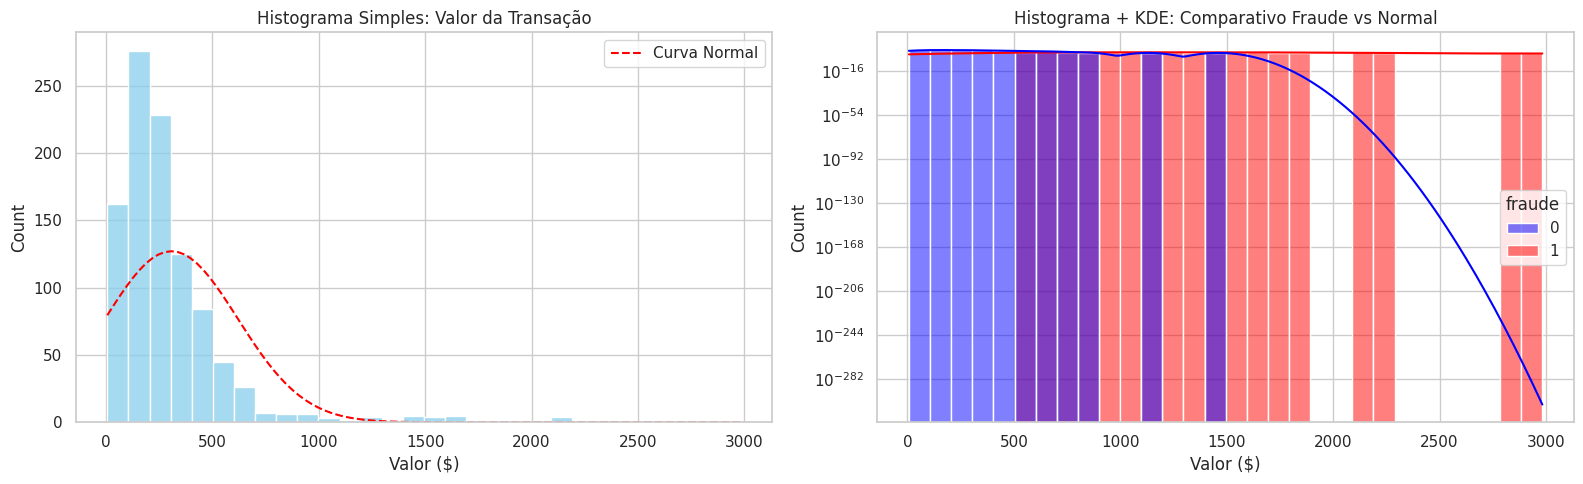

In [16]:
# 2. HISTOGRAMA E DISTPLOT (Entendendo a Distribuição)
# ==============================================================================
# O QUE É: Mostra a frequência dos dados. Fundamental para ver se é uma "Sino" (Normal) ou se tem cauda longa.

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Histograma Simples
sns.histplot(data=df, x='valor_transacao', bins=30, kde=False, color='skyblue', ax=ax[0])
ax[0].set_title('Histograma Simples: Valor da Transação')
ax[0].set_xlabel('Valor ($)')

# Adicionando a curva normal (gaussiana) ao histograma simples
from scipy.stats import norm
mu, sigma = df['valor_transacao'].mean(), df['valor_transacao'].std()
x_values = np.linspace(df['valor_transacao'].min(), df['valor_transacao'].max(), 100)
# Calcular a PDF e escalar para corresponder à altura do histograma (contagens)
bin_width = (df['valor_transacao'].max() - df['valor_transacao'].min()) / 30 # Aproximação da largura da bin
ax[0].plot(x_values, norm.pdf(x_values, mu, sigma) * len(df) * bin_width, color='red', linestyle='--', label='Curva Normal')
ax[0].legend() # Mostra a legenda para a curva normal

# Gráfico 2: Histograma com KDE (Kernel Density Estimation) e hue (Separação por classe)
sns.histplot(data=df, x='valor_transacao', hue='fraude', bins=30, kde=True, palette={0: 'blue', 1: 'red'}, ax=ax[1])
ax[1].set_title('Histograma + KDE: Comparativo Fraude vs Normal')
ax[1].set_xlabel('Valor ($)')
ax[1].set_yscale('log') # Truque de consultor: Escala Log para ver os outliers de fraude que são poucos!

plt.tight_layout()
plt.show()

**INSIGHT DE CONSULTORIA:**
Note no gráfico da direita (com escala log): As transações fraudulentas (Vermelho)
estão deslocadas para a direita. Isso visualmente confirma que 'valor alto' é um forte preditor.

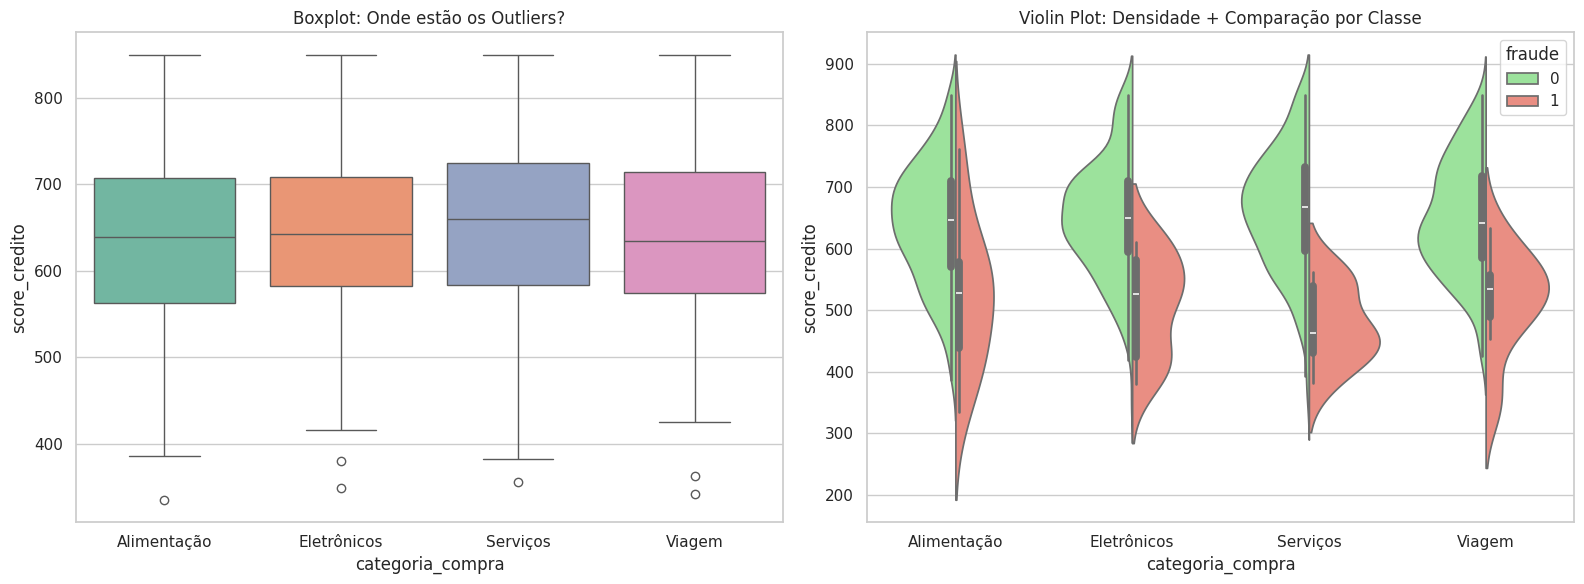

In [24]:
# 3. BOXPLOT VS VIOLIN PLOT (Caçando Outliers e Densidade)
# ==============================================================================
# O QUE É: Boxplot mostra quartis e outliers (pontos fora da curva). Violin mostra isso + a "gordura" (densidade) dos dados.

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Clássico
sns.boxplot(data=df, x='categoria_compra', y='score_credito', ax=ax[0], palette="Set2")
ax[0].set_title('Boxplot: Onde estão os Outliers?')

# Violin Plot
sns.violinplot(data=df, x='categoria_compra', y='score_credito', hue='fraude', split=True, ax=ax[1], palette={0: 'lightgreen', 1: 'salmon'})
ax[1].set_title('Violin Plot: Densidade + Comparação por Classe')

plt.tight_layout()
plt.show()

**INSIGHT DE CONSULTORIA:**
Olhe o Violin Plot (direita). A categoria 'Eletrônicos' tem uma "barriga" longa e fina na cor salmão (fraude).
Isso mostra que em fraudes de eletrônicos, os valores variam muito mais do que em compras legítimas.
O Boxplot (esquerda) mostra apenas os pontos pretos como outliers, mas esconde a forma da distribuição.

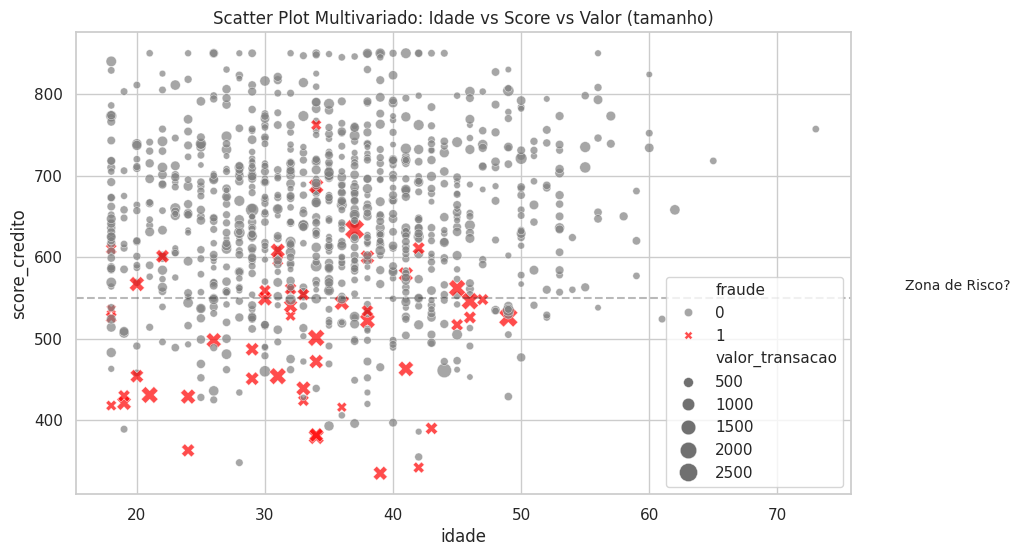

In [18]:
# 4. SCATTER PLOT (Relacionamento entre Variáveis)
# ==============================================================================
# O QUE É: Plota X contra Y.

plt.figure(figsize=(10, 6))

# Usando tamanho (size) e cor (hue) para adicionar dimensões ao gráfico 2D
sns.scatterplot(
    data=df,
    x='idade',
    y='score_credito',
    hue='fraude',
    style='fraude',
    size='valor_transacao',
    sizes=(20, 200),
    palette={0: 'grey', 1: 'red'},
    alpha=0.7
)

plt.title('Scatter Plot Multivariado: Idade vs Score vs Valor (tamanho)')
plt.axhline(y=550, color='k', linestyle='--', alpha=0.3) # Linha de corte visual
plt.text(80, 560, "Zona de Risco?", fontsize=10)
plt.show()

**INSIGHT DE CONSULTORIA:**
Observe os pontos vermelhos. Eles tendem a se agrupar na parte inferior (Score baixo)?
Sim! O gráfico mostra que raramente temos fraude com Score > 750 (parte superior vazia de vermelhos).
Essa é uma regra de negócio que você acabou de descobrir visualmente!

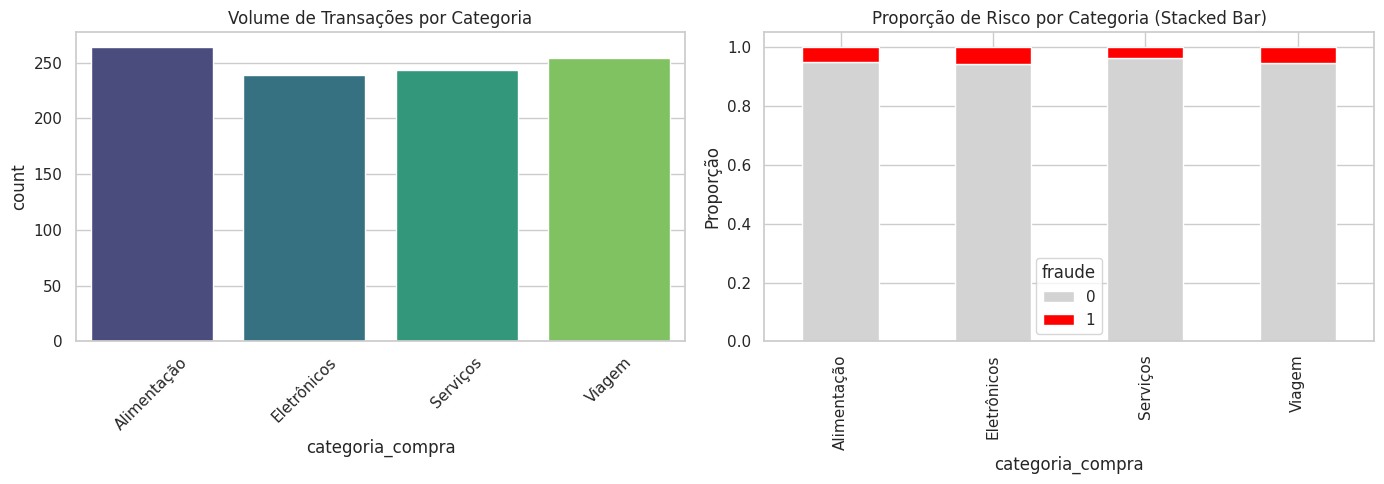

In [19]:
# 5. COUNTPLOT (Análise de Categóricos)
# ==============================================================================
# O QUE É: Conta quantos registros existem em cada categoria.

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Contagem simples
sns.countplot(data=df, x='categoria_compra', ax=ax[0], palette='viridis')
ax[0].set_title('Volume de Transações por Categoria')
ax[0].tick_params(axis='x', rotation=45)

# Contagem quebrada por fraude (Normalizado para ver proporção)
# Para consultoria, números absolutos as vezes enganam. Vamos ver proporção.
crosstab_norm = pd.crosstab(df['categoria_compra'], df['fraude'], normalize='index')
crosstab_norm.plot(kind='bar', stacked=True, color=['lightgrey', 'red'], ax=ax[1])
ax[1].set_title('Proporção de Risco por Categoria (Stacked Bar)')
ax[1].set_ylabel('Proporção')

plt.tight_layout()
plt.show()

**INSIGHT DE CONSULTORIA:**
O gráfico de barras empilhadas (direita) é poderoso para apresentações.
Mesmo que 'Alimentação' tenha muitas transações (gráfico esquerda),
talvez 'Eletrônicos' tenha uma barra vermelha proporcionalmente maior (direita),
indicando onde o time de segurança deve focar.

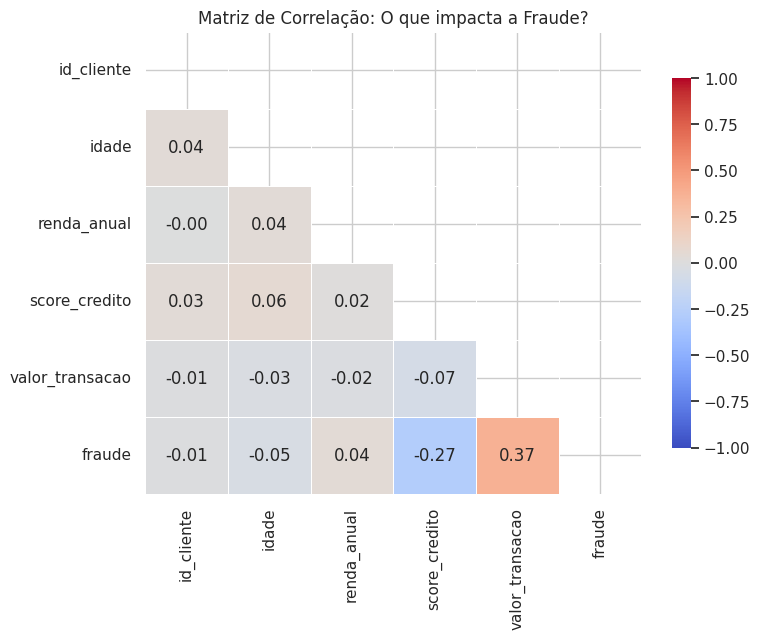

In [25]:
# 6. CORRELATION HEATMAP (Matriz de Correlação)
# ==============================================================================
# O QUE É: Mapa de calor mostrando o quão ligadas duas variáveis estão (-1 a 1).

plt.figure(figsize=(8, 6))

# Selecionando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr(method="spearman")

# Máscara para ocultar a parte superior (triângulo duplicado) - deixa o visual mais limpo/profissional
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    vmax=1,
    vmin=-1,
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlação: O que impacta a Fraude?')
plt.show()

**INSIGHT DE CONSULTORIA:**
Procure as cores fortes na linha/coluna 'fraude'.
- Se 'valor_transacao' tem cor vermelha forte (positiva) com 'fraude', é um preditor forte.
- Se 'score_credito' tem cor azul forte (negativa), significa que quanto maior o score, menor a chance de fraude.
Isso valida as features que vamos colocar no pipeline de ML.

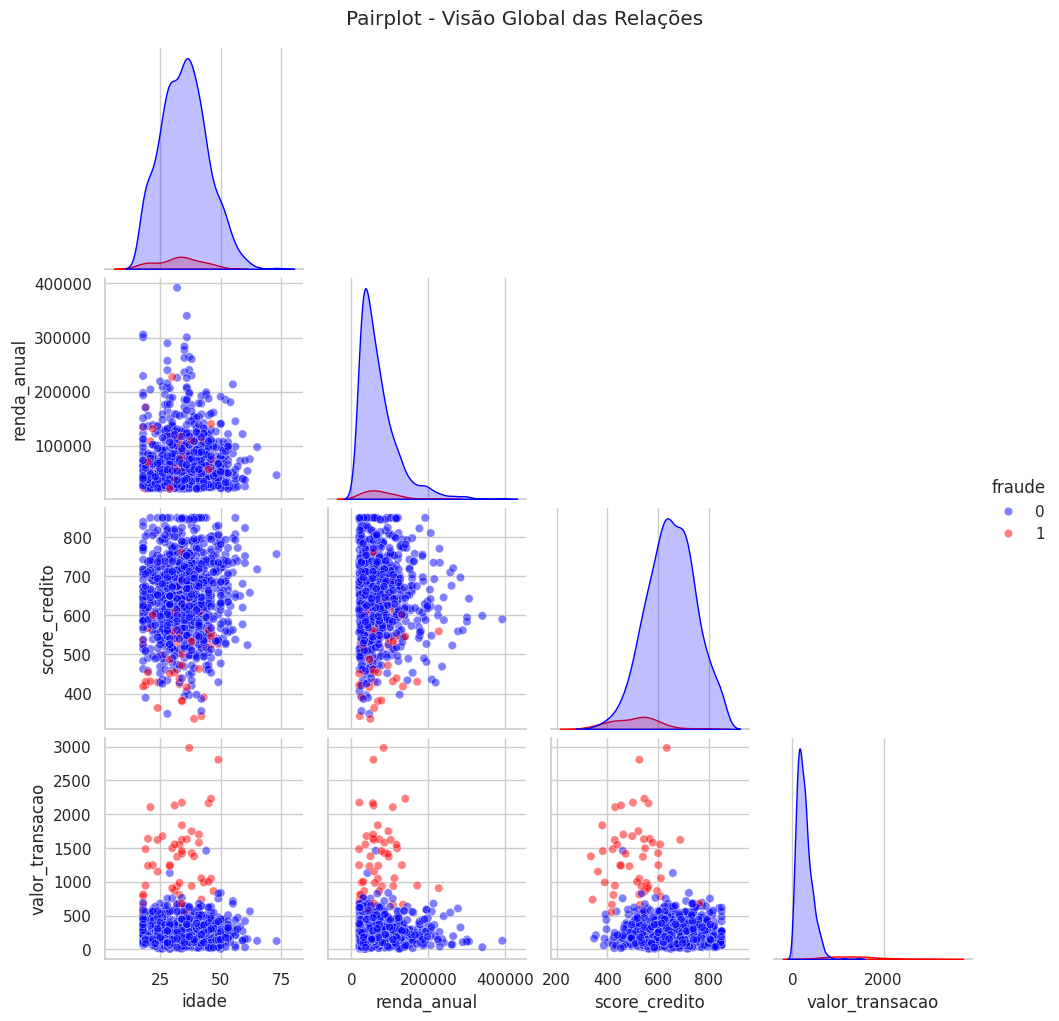

In [21]:
# 7. PAIRPLOT (O Resumo da Ópera)
# ==============================================================================
# O QUE É: Plota tudo contra tudo.

# Vamos selecionar apenas algumas colunas para não poluir
cols_to_plot = ['idade', 'renda_anual', 'score_credito', 'valor_transacao', 'fraude']

sns.pairplot(
    df[cols_to_plot],
    hue='fraude',
    palette={0: 'blue', 1: 'red'},
    corner=True, # Remove redundância
    plot_kws={'alpha': 0.5}
)
plt.suptitle("Pairplot - Visão Global das Relações", y=1.02)
plt.show()
